
🚀 FINAL BALANCED MODEL RESULTS
Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 8, 'class_weight': 'balanced'}
CV Avg Accuracy: 79.89%
Test Accuracy:   80.98%
Final Recall:     85.29%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78        82
           1       0.81      0.85      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.80      0.81       184
weighted avg       0.81      0.81      0.81       184



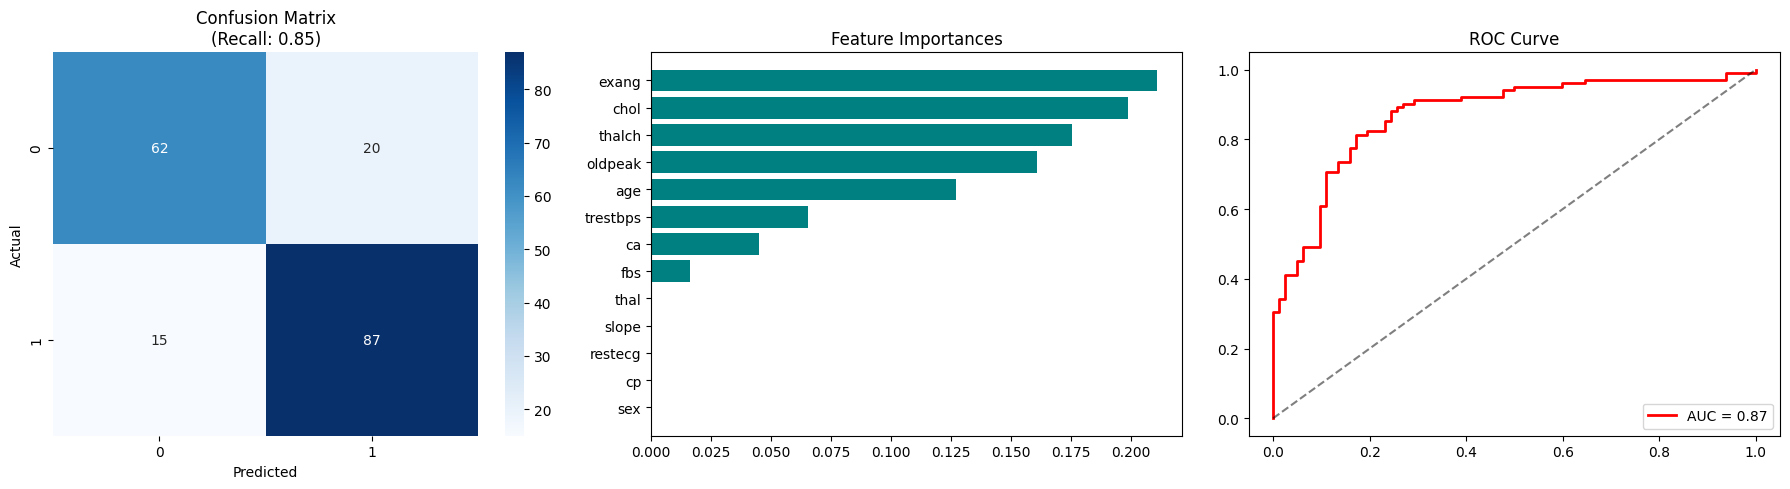


✅ All set! 3 optimized files saved for your API project.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, recall_score, precision_score
import joblib

# --- 1. Data Loading and Preprocessing ---
df = pd.read_csv("../data/heart_disease_uci.csv").drop(['id', 'dataset'], axis=1)

# Handling missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# Categorical data encoding
encoders = {}
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Target preparation (0: Healthy, 1: Diseased)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
X = df.drop(['target', 'num'], axis=1)
y = df['target']

# Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. Hyperparameter Tuning (RandomizedSearchCV) ---
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=15,
                                   cv=5, n_jobs=-1, scoring='accuracy', random_state=42)
random_search.fit(X_train_scaled, y_train)

best_model = random_search.best_estimator_

# --- 3. Model Evaluation and Performance Metrics ---
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5)

# Applying custom threshold for recall optimization
probs = best_model.predict_proba(X_test_scaled)[:, 1]
optimized_threshold = 0.45
y_pred_final = (probs >= optimized_threshold).astype(int)

# Printing performance summary
print("\n" + "="*45)
print("🚀 FINAL BALANCED MODEL RESULTS")
print("="*45)
print(f"Best Params: {random_search.best_params_}")
print(f"CV Avg Accuracy: {np.mean(cv_scores)*100:.2f}%")
print(f"Test Accuracy:   {accuracy_score(y_test, y_pred_final)*100:.2f}%")
print(f"Final Recall:     {recall_score(y_test, y_pred_final)*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_final))
print("="*45)

# --- 4. Visualizations ---
plt.figure(figsize=(18, 5))

# Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix\n(Recall: {recall_score(y_test, y_pred_final):.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Feature Importance
plt.subplot(1, 3, 2)
importances = best_model.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='teal')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Feature Importances')

# ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='red', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# --- 5. Model Deployment Export ---
joblib.dump(best_model, 'heart_disease_best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'label_encoders.pkl')

print("\n✅ All set! 3 optimized files saved for your API project.")

In [ ]:
%%sql
